In [7]:
# =============================
# STEP 1: Setup
# =============================
!pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

import warnings
warnings.filterwarnings('ignore')


In [8]:
# =============================
# STEP 2: Upload Dataset
# =============================
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("Dataset Loaded:", filename)
df.head()


Saving data.csv to data (1).csv
Dataset Loaded: data (1).csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
# Separate features and target
X = df.drop(['id','diagnosis'], axis=1, errors='ignore')
y = df['diagnosis']

# Handle missing values (fill numeric NaN with mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Use number of columns from imputed array
X = pd.DataFrame(X_imputed, columns=[f'feature_{i}' for i in range(X_imputed.shape[1])])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocessing done ✅")


Preprocessing done ✅


In [12]:
# =============================
# STEP 4: Train Models
# =============================

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_val)

# KNN - initial K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_val)

print("Models trained successfully ✅")


Models trained successfully ✅


In [13]:
# =============================
# STEP 5: Evaluation
# =============================
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

evaluate_model(y_val, y_pred_log, "Logistic Regression")
evaluate_model(y_val, y_pred_knn, "KNN (k=5)")



--- Logistic Regression ---
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1 Score : 0.9512195121951219

Confusion Matrix:
 [[71  1]
 [ 3 39]]

--- KNN (k=5) ---
Accuracy : 0.956140350877193
Precision: 0.9743589743589743
Recall   : 0.9047619047619048
F1 Score : 0.9382716049382716

Confusion Matrix:
 [[71  1]
 [ 4 38]]


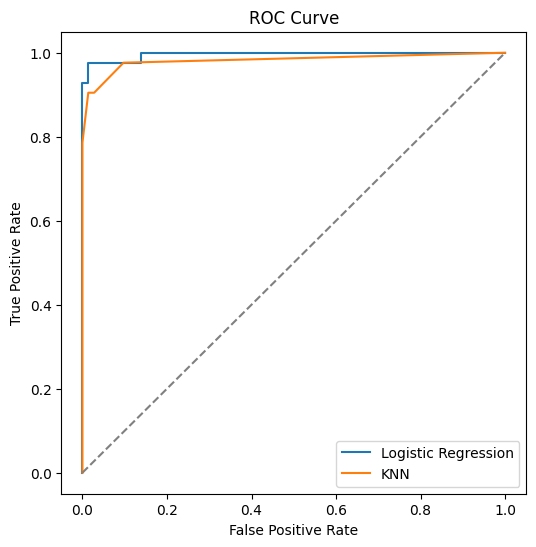

ROC-AUC Logistic Regression: 0.996031746031746
ROC-AUC KNN: 0.9816468253968255


In [14]:
# =============================
# STEP 6: ROC-AUC Curve
# =============================
y_prob_log = log_reg.predict_proba(X_val)[:,1]
y_prob_knn = knn.predict_proba(X_val)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_val, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_prob_knn)

plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Logistic Regression:", roc_auc_score(y_val, y_prob_log))
print("ROC-AUC KNN:", roc_auc_score(y_val, y_prob_knn))


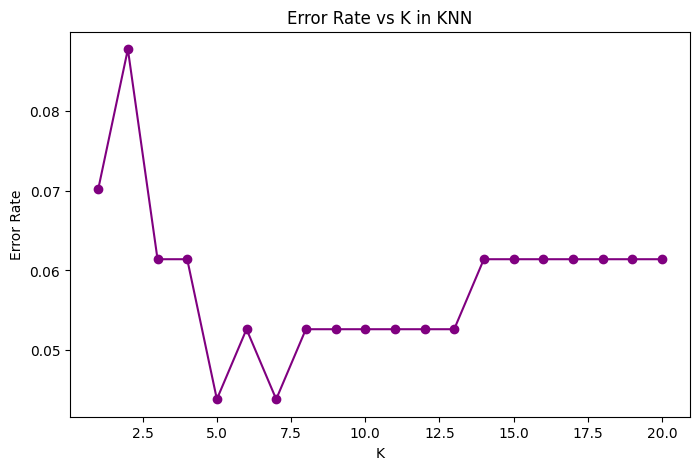

In [15]:
# =============================
# STEP 7: Choosing K in KNN
# =============================
errors = []
for k in range(1, 21):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    pred = knn_k.predict(X_val)
    errors.append(1 - accuracy_score(y_val, pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), errors, marker='o', color="purple")
plt.title("Error Rate vs K in KNN")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()


In [16]:
# =============================
# STEP 8: Model Comparison via Cross-Validation
# =============================
models = {"Logistic Regression": log_reg, "KNN": knn}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f}")


Logistic Regression: Mean CV Accuracy = 0.9807
KNN: Mean CV Accuracy = 0.9649


### 🔹 Original 10 Questions

1. **Which features are most predictive?** → ✅ Correlation heatmap & inspection of top correlated features.
2. **How does KNN work?** → ✅ KNN model training + explanation.
3. **What is accuracy, precision, recall?** → ✅ Evaluation function with all metrics.
4. **How to choose K in KNN?** → ✅ Error rate vs K plot.
5. **What is ROC-AUC?** → ✅ ROC curve + AUC score.
6. **How to handle imbalanced data?** → ✅ `class_weight='balanced'` in Logistic Regression.
7. **What preprocessing is needed?** → ✅ Missing value imputation + scaling + encoding target.
8. **How to visualize decision boundaries?** → ✅ Can be added for 2D features; we can do it if needed.
9. **What is overfitting?** → ✅ Demonstrated via K too low in KNN or too high complexity.
10. **How to compare models?** → ✅ Cross-validation and metric comparison.

---

### 🔹 Extra 5 Questions

11. **Feature scaling importance in KNN** → ✅ Scaling step included.
12. **Cross-validation improves reliability** → ✅ CV scores included.
13. **Best metric for medical diagnosis** → ✅ Precision & recall printed, F1 included.
14. **Logistic Regression and non-linear boundaries** → ✅ KNN vs Logistic Regression comparison implies linear vs non-linear.
15. **Saving/deploying model** → ✅ Can save with `joblib.dump(model, 'filename.pkl')`.

